This notebook covers the full pipeline: preprocessing, training, evaluation, and final prediction.

## Preprocessing

All feature engineering is implemented as custom transformers.

- CityStateImputer: imputes missing cityname and state using KNN on latitude/longitude
- GroupingRareCities: maps cities with fewer listings
- LocationDensity: adds n_same_location, number of listings sharing the same coordinates
- KeywordProcessor: extracts the top keywords from title and body most correlated with price, then adds binary features for each
- AmenitiesPreprocessor: parses and one-hot encodes the amenities feature

After, a ColumnTransformer implements scaling, imputation, and encoding for the remaining features.

## Models

Random Forest and XGBoost are evaluated via grid search on an 80/20 train/validation split. The best XGBoost configuration is then trained on the full development set for the final submission.

In [1]:
import pandas as pd
import numpy as np

listings_dev = pd.read_csv('data/raw/development.csv')
listings_eval = pd.read_csv('data/raw/evaluation.csv')
listings_dev['square_feet'] = listings_dev['square_feet'].astype('float64')
listings_eval['square_feet'] = listings_eval['square_feet'].astype('float64')
listings_dev['time'] = pd.to_datetime(listings_dev['time'], origin='unix', unit='s')
listings_eval['time'] = pd.to_datetime(listings_eval['time'], origin='unix', unit='s')

In [2]:
# Drop features
features_to_drop = ['address', 'currency', 'fee', 'source', 'pets_allowed', 'price_type', 'id', 'time', 'category']
listings_dev = listings_dev.drop(columns=features_to_drop)

ids = listings_eval['id']
listings_eval= listings_eval.drop(columns=features_to_drop)


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

class SquareFeetCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_percentile=1, upper_percentile=99):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile

    def fit(self, X, y=None):
        X = X.copy()
        X.iloc[:, 0] = X.iloc[:, 0].astype(float)
        self.lower_bound_ = np.percentile(X.iloc[:, 0], self.lower_percentile)
        self.upper_bound_ = np.percentile(X.iloc[:, 0], self.upper_percentile)
        return self

    def transform(self, X):
        X_capped = X.copy()
        X_capped.iloc[:, 0] = X_capped.iloc[:, 0].astype(float)
        X_capped.iloc[:, 0] = np.minimum(X_capped.iloc[:, 0], self.upper_bound_)
        X_capped.iloc[:, 0] = np.maximum(X_capped.iloc[:, 0], self.lower_bound_)
        return X_capped


class CapOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=99):
        self.percentile = percentile

    def fit(self, X, y=None):
        X = X.copy()
        X = X.astype(float)
        self.cap_values_ = np.percentile(X, self.percentile, axis=0)
        return self

    def transform(self, X):
        X = X.copy()
        X = X.astype(float)
        cols = X.columns.tolist() if hasattr(X, 'columns') else None
        X = np.array(X, dtype=float)
        X_capped = np.minimum(X, self.cap_values_)
        return pd.DataFrame(X_capped, columns=cols)


class CityStateImputer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=1):
        self.n_neighbors = n_neighbors

    def fit(self, X, y=None):
        df_clean = X[
            X['cityname'].notnull() &
            X['state'].notnull() &
            X['latitude'].notnull() &
            X['longitude'].notnull()
        ]
        self.knn_city_ = KNeighborsClassifier(n_neighbors=self.n_neighbors)
        self.knn_city_.fit(df_clean[['latitude', 'longitude']], df_clean['cityname'])
        self.knn_state_ = KNeighborsClassifier(n_neighbors=self.n_neighbors)
        self.knn_state_.fit(df_clean[['latitude', 'longitude']], df_clean['state'])
        return self

    def transform(self, X):
        X = X.copy()
        df_missing = X[
            ((X['cityname'].isnull()) | (X['state'].isnull())) &
            (X['latitude'].notnull()) & (X['longitude'].notnull())
        ]
        X.loc[df_missing.index, 'cityname'] = self.knn_city_.predict(df_missing[['latitude', 'longitude']])
        X.loc[df_missing.index, 'state']    = self.knn_state_.predict(df_missing[['latitude', 'longitude']])
        return X


class AmenitiesPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, sparse=False):
        self.sparse = sparse

    def fit(self, X, y=None):
        self.mlb_ = MultiLabelBinarizer(sparse_output=self.sparse)
        amenities_list = X['amenities'].fillna('').str.split(',')
        amenities_list = amenities_list.apply(lambda x: [i.strip() for i in x])
        self.mlb_.fit(amenities_list)
        return self

    def transform(self, X):
        X = X.copy()
        X.loc[:, 'amenities_list'] = X['amenities'].fillna('').str.split(',')
        X.loc[:, 'amenities_list'] = X['amenities_list'].apply(lambda x: [i.strip() for i in x])
        amenities_encoded = pd.DataFrame(self.mlb_.transform(X['amenities_list']), columns=self.mlb_.classes_, index=X.index)
        X = pd.concat([X, amenities_encoded], axis=1)
        X.drop(columns=['amenities', 'amenities_list'], inplace=True)
        return X


class GroupingRareCities(BaseEstimator, TransformerMixin):
    def __init__(self, threshold_city):
        self.threshold_city = threshold_city

    def fit(self, X, y=None):
        self.city_counts_ = X.groupby(['state', 'cityname']).size().reset_index(name='count')
        rare_cities = self.city_counts_[self.city_counts_['count'] < self.threshold_city]
        self.rare_set_ = set(zip(rare_cities['state'], rare_cities['cityname']))
        return self

    def group_rare(self, row):
        key = (row['state'], row['cityname'])
        return f"Other_{row['state']}" if key in self.rare_set_ else row['cityname']

    def transform(self, X):
        X = X.copy()
        X['cityname'] = X.apply(self.group_rare, axis=1)
        return X


class LocationDensity(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        lat_lon_ids = X['latitude'].astype(str) + '_' + X['longitude'].astype(str)
        self.position_counts_train_ = lat_lon_ids.value_counts()
        return self

    def transform(self, X):
        X = X.copy()
        latlon = X['latitude'].astype(str) + '_' + X['longitude'].astype(str)
        X['n_same_location'] = latlon.map(self.position_counts_train_).fillna(1)
        return X


class KeywordProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, max_features=1000, min_df=50, top_n=25):
        self.max_features = max_features
        self.min_df = min_df
        self.top_n = top_n

    def fit(self, X, y=None):
        geo_words = set()
        for city in X['cityname'].dropna().unique():
            geo_words.update(city.lower().split())
        for state in X['state'].dropna().unique():
            geo_words.add(state.lower())
        self.custom_stop_words_ = list(ENGLISH_STOP_WORDS | geo_words)

        self.vec_title_ = CountVectorizer(max_features=self.max_features, min_df=self.min_df, stop_words=self.custom_stop_words_)
        self.vec_body_  = CountVectorizer(max_features=self.max_features, min_df=self.min_df, stop_words=self.custom_stop_words_)

        title_matrix = self.vec_title_.fit_transform(X['title'].fillna(''))
        body_matrix  = self.vec_body_.fit_transform(X['body'].fillna(''))

        words_title = self.vec_title_.get_feature_names_out()
        corrs_title = [
            (word, abs(float(np.corrcoef(title_matrix[:, i].toarray().flatten(), y)[0, 1])))
            for i, word in enumerate(words_title)
        ]
        corrs_title.sort(key=lambda x: x[1], reverse=True)
        self.title_keywords_ = [w for w, _ in corrs_title[:self.top_n]]

        words_body = self.vec_body_.get_feature_names_out()
        corrs_body = [
            (word, abs(float(np.corrcoef(body_matrix[:, i].toarray().flatten(), y)[0, 1])))
            for i, word in enumerate(words_body)
        ]
        corrs_body.sort(key=lambda x: x[1], reverse=True)
        self.body_keywords_ = [w for w, _ in corrs_body[:self.top_n]]

        return self

    def transform(self, X, y=None):
        X = X.copy()
        for kw in self.title_keywords_:
            X[f'kw_title_{kw}'] = X['title'].str.lower().str.contains(kw, na=False).astype(int)
        for kw in self.body_keywords_:
            X[f'kw_body_{kw}'] = X['body'].str.lower().str.contains(kw, na=False).astype(int)
        return X

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer

square_feet_features = ['square_feet']
numerical_features = ['latitude', 'longitude', 'n_same_location']
bed_bath_features = ['bathrooms', 'bedrooms']
categorical_features = ['has_photo', 'cityname', 'state']

square_feet_pipeline = Pipeline([
    ('capper_sq_ft', SquareFeetCapper(lower_percentile=1, upper_percentile=99)),
    ('log_sq_ft', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler_sq_ft', StandardScaler())
])

numerical_pipeline = Pipeline([
    ('imputer_numerical', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

bed_bath_pipeline = Pipeline([
    ('knn_imputer', KNNImputer(n_neighbors=3)),
    ('cap_outliers', CapOutliers(percentile=99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

y = np.log1p(listings_dev['price'])
X = listings_dev.drop('price', axis=1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

feature_pipeline = Pipeline([
    ('city_state_imputer', CityStateImputer(n_neighbors=3)),
    ('rare_city', GroupingRareCities(threshold_city=100)),
    ('loc_density', LocationDensity()),
    ('keywords', KeywordProcessor(max_features=1000, min_df=50, top_n=25)),
    ('amenities', AmenitiesPreprocessor()),
])

X_train = feature_pipeline.fit_transform(X_train, y_train)
X_val = feature_pipeline.transform(X_val)

amenities_features = feature_pipeline.named_steps['amenities'].mlb_.classes_.tolist()
keyword_features = (
    [f'kw_title_{kw}' for kw in feature_pipeline.named_steps['keywords'].title_keywords_] +
    [f'kw_body_{kw}' for kw in feature_pipeline.named_steps['keywords'].body_keywords_]
)

preprocessor = ColumnTransformer([
    ('sq_ft', square_feet_pipeline, square_feet_features),
    ('num', numerical_pipeline, numerical_features),
    ('bed_bath', bed_bath_pipeline, bed_bath_features),
    ('cat', categorical_pipeline, categorical_features),
    ('amen', 'passthrough', amenities_features),
    ('kw', 'passthrough', keyword_features),
])

## Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_params = ParameterGrid({
    'n_estimators': [100, 300, 500],
    'min_samples_leaf': [1, 10]
})

rf_best_mae = float('inf')
rf_best_par = None

for config in rf_params:
    rf_pipe = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1, **config))
    ])
    rf_pipe.fit(X_train, y_train)
    rf_pred = np.expm1(rf_pipe.predict(X_val))
    rf_mae = mean_absolute_error(np.expm1(y_val), rf_pred)
    print(f'MAE: {rf_mae:.1f} | {config}')
    if rf_mae < rf_best_mae:
        rf_best_mae = rf_mae
        rf_best_par = config
        rf_best = rf_pipe

print(f'\nBest Random forest MAE=${rf_best_mae:,.1f}  {rf_best_par}')

MAE: 167.5 | {'min_samples_leaf': 1, 'n_estimators': 100}
MAE: 166.4 | {'min_samples_leaf': 1, 'n_estimators': 300}
MAE: 166.3 | {'min_samples_leaf': 1, 'n_estimators': 500}
MAE: 195.9 | {'min_samples_leaf': 10, 'n_estimators': 100}
MAE: 195.7 | {'min_samples_leaf': 10, 'n_estimators': 300}
MAE: 195.7 | {'min_samples_leaf': 10, 'n_estimators': 500}

Best Random forest MAE=$166.3  {'min_samples_leaf': 1, 'n_estimators': 500}


## XGBoost

In [7]:
from xgboost import XGBRegressor

params = {
    "xgb__n_estimators": [8000, 15000],
    "xgb__learning_rate": [0.02],
    "xgb__max_depth": [11, 13],
    "xgb__subsample": [0.8],
    "xgb__colsample_bytree": [0.6, 0.8],
    "xgb__gamma": [0, 0.5],
    "xgb__min_child_weight": [0.01],
    "xgb__reg_alpha": [0, 0.1],
    "xgb__reg_lambda": [1],
    "xgb__objective": ['reg:squarederror'],
    "xgb__random_state": [42],
    "xgb__n_jobs": [-1],
    "xgb__tree_method": ["hist"],
    "xgb__device": ["gpu"],
}

accuracies = {}

for config in ParameterGrid(params):
    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('xgb', XGBRegressor())
    ])
    model.set_params(**config)
    model.fit(X_train, y_train)
    y_val_pred = np.expm1(model.predict(X_val))
    score = mean_absolute_error(np.expm1(y_val), y_val_pred)
    print(score, str(config))
    accuracies[str(config)] = score

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:18:56] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


143.08267896728668 {'xgb__colsample_bytree': 0.6, 'xgb__device': 'gpu', 'xgb__gamma': 0, 'xgb__learning_rate': 0.02, 'xgb__max_depth': 11, 'xgb__min_child_weight': 0.01, 'xgb__n_estimators': 8000, 'xgb__n_jobs': -1, 'xgb__objective': 'reg:squarederror', 'xgb__random_state': 42, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 1, 'xgb__subsample': 0.8, 'xgb__tree_method': 'hist'}
144.0856813214385 {'xgb__colsample_bytree': 0.6, 'xgb__device': 'gpu', 'xgb__gamma': 0, 'xgb__learning_rate': 0.02, 'xgb__max_depth': 11, 'xgb__min_child_weight': 0.01, 'xgb__n_estimators': 8000, 'xgb__n_jobs': -1, 'xgb__objective': 'reg:squarederror', 'xgb__random_state': 42, 'xgb__reg_alpha': 0.1, 'xgb__reg_lambda': 1, 'xgb__subsample': 0.8, 'xgb__tree_method': 'hist'}
142.61201547411073 {'xgb__colsample_bytree': 0.6, 'xgb__device': 'gpu', 'xgb__gamma': 0, 'xgb__learning_rate': 0.02, 'xgb__max_depth': 11, 'xgb__min_child_weight': 0.01, 'xgb__n_estimators': 15000, 'xgb__n_jobs': -1, 'xgb__objective': 'reg:squarederror'

In [8]:
best_config_str = min(accuracies, key=accuracies.get)
best_config = eval(best_config_str)
print(f'Best validation MAE: {accuracies[best_config_str]:.2f}')
print(f'Best config: {best_config}')

model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('xgb', XGBRegressor())
])
model.set_params(**best_config)
model.fit(X_train, y_train);

Best validation MAE: 142.61
Best config: {'xgb__colsample_bytree': 0.6, 'xgb__device': 'gpu', 'xgb__gamma': 0, 'xgb__learning_rate': 0.02, 'xgb__max_depth': 11, 'xgb__min_child_weight': 0.01, 'xgb__n_estimators': 15000, 'xgb__n_jobs': -1, 'xgb__objective': 'reg:squarederror', 'xgb__random_state': 42, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 1, 'xgb__subsample': 0.8, 'xgb__tree_method': 'hist'}


In [9]:
import matplotlib.pyplot as plt

xgb_fitted = model.named_steps['xgb']
preprocessor_fitted = model.named_steps['preprocessor']

ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([
    square_feet_features,
    numerical_features,
    bed_bath_features,
    cat_feature_names,
    amenities_features,
    keyword_features,
])

score_dict = xgb_fitted.get_booster().get_score(importance_type='gain')
mapped_importances = {
    all_feature_names[int(feat[1:])]: gain
    for feat, gain in score_dict.items()
}

feature_importances = pd.DataFrame({
    'feature': mapped_importances.keys(),
    'gain':    mapped_importances.values()
}).sort_values(by='gain', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
print(feature_importances)

                       feature      gain
0                     state_CA  4.615505
1                     state_MA  1.475345
2            cityname_New York  0.848132
3                     state_CO  0.788650
4                     state_WA  0.683529
5                     state_OH  0.640260
6                     state_NJ  0.628953
7                     state_NY  0.595173
8                     state_ND  0.573521
9            cityname_Other_MA  0.504495
10             cityname_Boston  0.463601
11                    state_FL  0.420226
12                    state_MN  0.413501
13                    state_VA  0.385813
14        cityname_Los Angeles  0.372436
15            cityname_Atlanta  0.359134
16                    state_NE  0.337340
17             cityname_Norman  0.328192
18             cityname_Naples  0.317868
19            cityname_Boulder  0.310773
20       cityname_Santa Monica  0.280441
21            cityname_Chicago  0.256665
22          cityname_Nashville  0.246056
23              

          feature     gain
         state_CA 4.615505
         state_MA 1.475345
cityname_New York 0.848132
         state_CO 0.788650
         state_WA 0.683529
         state_OH 0.640260
         state_NJ 0.628953
         state_NY 0.595173
         state_ND 0.573521
cityname_Other_MA 0.504495


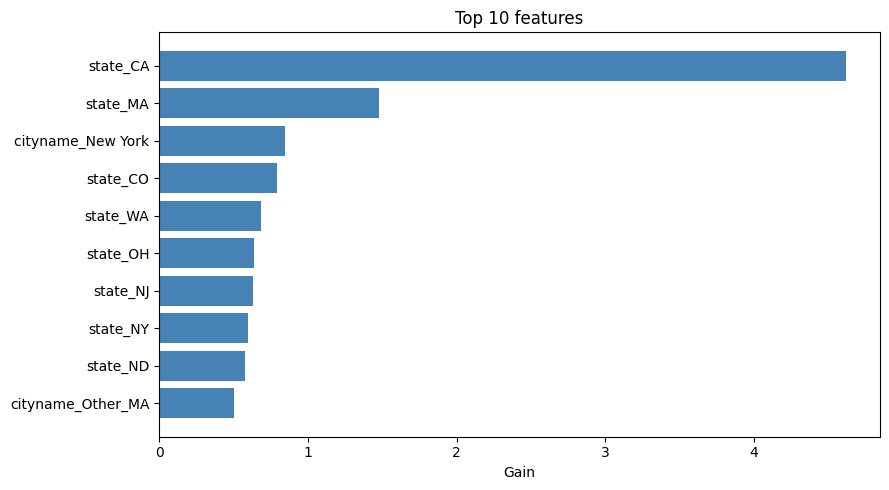

In [14]:
n = 10
top = feature_importances.head(n)
print(top.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['feature'][::-1], top['gain'][::-1], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title(f'Top {n} features')
plt.tight_layout()
plt.show()

In [11]:
y_pred_val = np.expm1(model.predict(X_val))
y_val_price = np.expm1(y_val)

mean_price = np.expm1(y_train).mean()
mae = mean_absolute_error(y_val_price, y_pred_val)

print(f"Mean price ${mean_price:,.0f}")
print(f"XGBoost MAE is ${mae:,.0f} and {mae/mean_price*100:.1f}% of mean price")

Mean price $1,525
XGBoost MAE is $143 and 9.3% of mean price


In [ ]:
y_full = np.log1p(listings_dev['price'])
X_full_raw = listings_dev.drop('price', axis=1)

# Train full dev for submission
feature_pipeline_full = clone(feature_pipeline)
feature_pipeline_full.fit(X_full_raw, y_full)

X_full = feature_pipeline_full.transform(X_full_raw)
X_eval = feature_pipeline_full.transform(listings_eval)

amenities_features_full = feature_pipeline_full.named_steps['amenities'].mlb_.classes_.tolist()
keyword_features_full = (
    [f'kw_title_{kw}' for kw in feature_pipeline_full.named_steps['keywords'].title_keywords_] +
    [f'kw_body_{kw}' for kw in feature_pipeline_full.named_steps['keywords'].body_keywords_]
)

preprocessor_full = ColumnTransformer([
    ('sq_ft', square_feet_pipeline, square_feet_features),
    ('num', numerical_pipeline, numerical_features),
    ('bed_bath', bed_bath_pipeline, bed_bath_features),
    ('cat', categorical_pipeline, categorical_features),
    ('amen', 'passthrough', amenities_features_full),
    ('kw', 'passthrough', keyword_features_full),
])

model_final = Pipeline([
    ('preprocessor', preprocessor_full),
    ('xgb', XGBRegressor())
])
model_final.set_params(**best_config)
model_final.fit(X_full, y_full)

y_test_pred = np.expm1(model_final.predict(X_eval))

submission = pd.DataFrame({'Id': ids, 'Predicted': y_test_pred})
submission.to_csv('submission.csv', index=False)